# Pulpos gigantes del Cretácico: ¿quiénes eran?

Hace 100 millones de años, los océanos tenían cefalópodos de hasta 19 metros depredando como apex. Durante 370 millones de años, los apex marinos han sido vertebrados — entonces ¿quiénes eran estos invertebrados gigantes?

El paper resuelve la pregunta con 19 caracteres mandibulares. Aquí abrimos los datos.

**Paper:** Ikegami et al. (2026), *Earliest octopuses were giant top predators in Cretaceous oceans*, Science.
[DOI: 10.1126/science.aea6285](https://doi.org/10.1126/science.aea6285)

**Datos:** Figshare, CC BY 4.0 — [doi.org/10.6084/m9.figshare.29561630](https://doi.org/10.6084/m9.figshare.29561630)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-25-octopodos-gigantes-cretacico/notebook.ipynb)

> Video del canal: pendiente.

## El contexto

En el Cretácico Tardío (entre 100 y 72 millones de años atrás) aparecen dos fósiles muy raros: *Nanaimoteuthis jeletzkyi* y *Nanaimoteuthis haggarti*. Mandíbulas enormes, conservadas en sedimentos de la actual Columbia Británica.

El equipo midió 19 caracteres morfológicos en las mandíbulas de los dos fósiles y de 19 cefalópodos modernos. Luego proyectó esa matriz en 2 dimensiones (PCoA — análisis de coordenadas principales, una forma de aplanar muchas variables a un mapa 2D) usando distancia Gower como métrica. Así se ve dónde caen los fósiles en el espacio morfológico.

La pregunta es directa: ¿están con los **cirrados** (los pulpos "raros" de aguas profundas, tipo Dumbo) o con los **incirrados** (el linaje del *Octopus* de toda la vida)?

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_CIRRATE = '#2563EB'         # Azul CaM — cirrados modernos
COLOR_INCIRRATE_BENTHIC = '#059669'  # Verde — pulpos bentónicos
COLOR_INCIRRATE_PELAGIC = '#7C3AED'  # Violeta — pulpos pelágicos
COLOR_OUTGROUP = '#BBBBBB'        # Gris — Vampyroteuthis (outgroup)
COLOR_FOSIL = '#DC2626'           # Rojo — los 2 fósiles cretácicos

FUENTE = 'Fuente: Ikegami et al. (2026), Science · Datos: Figshare CC BY 4.0'

# ── Imports ──
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Estilo CaM (local → fallback GitHub raw) ──
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

# ── Carga de datos ──
pcoa = pd.read_csv('datos/morphospace_pcoa.csv')
gower = pd.read_csv('datos/distancia_gower_a_fosiles.csv')

# Varianza explicada (ya viene como columna constante en el CSV)
PC1_VAR = pcoa['pc1_var_pct'].iloc[0]
PC2_VAR = pcoa['pc2_var_pct'].iloc[0]

print(f'Taxa totales: {len(pcoa)}')
print(f'  Modernos: {(pcoa["age"] == "modern").sum()}')
print(f'  Fósiles:  {(pcoa["age"] == "fossil").sum()}')
print()
print(f'Varianza explicada: PC1={PC1_VAR:.1f}%, PC2={PC2_VAR:.1f}%, total={PC1_VAR+PC2_VAR:.1f}%')
print()
print('Composición por grupo:')
print(pcoa['group'].value_counts().to_string())

Taxa totales: 21
  Modernos: 19
  Fósiles:  2

Varianza explicada: PC1=50.1%, PC2=30.9%, total=81.1%

Composición por grupo:
group
cirrate                  9
incirrate_pelagic        7
incirrate_benthic        2
fossil_cretaceous        2
outgroup_vampyromorph    1


## El morphospace

Aquí está.

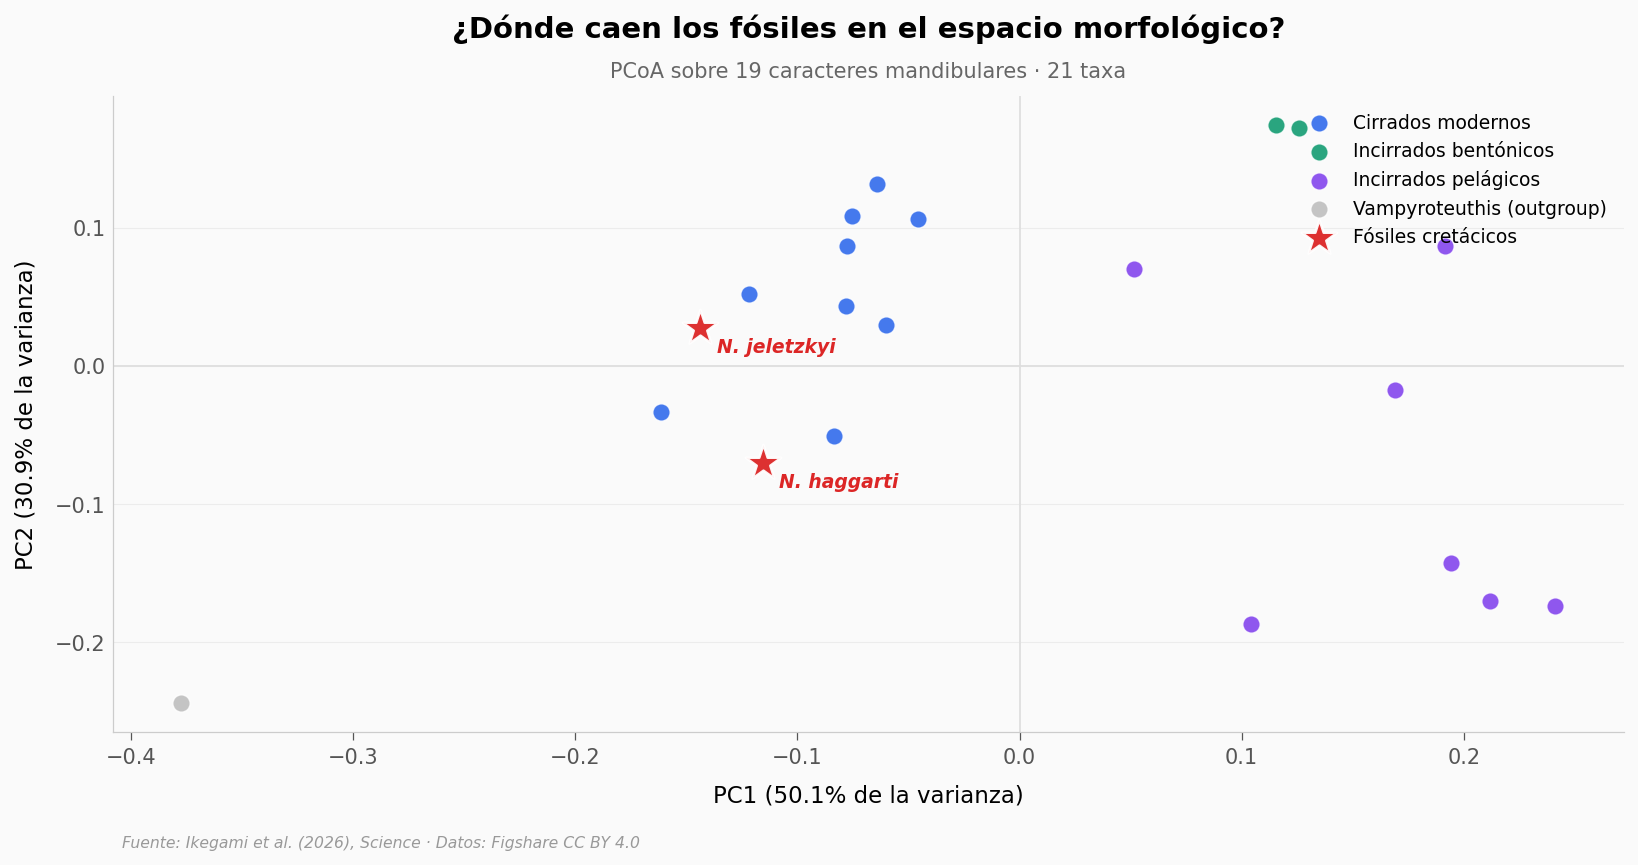

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Mapa de grupo → color
color_map = {
    'cirrate': COLOR_CIRRATE,
    'incirrate_benthic': COLOR_INCIRRATE_BENTHIC,
    'incirrate_pelagic': COLOR_INCIRRATE_PELAGIC,
    'outgroup_vampyromorph': COLOR_OUTGROUP,
    'fossil_cretaceous': COLOR_FOSIL,
}
label_map = {
    'cirrate': 'Cirrados modernos',
    'incirrate_benthic': 'Incirrados bentónicos',
    'incirrate_pelagic': 'Incirrados pelágicos',
    'outgroup_vampyromorph': 'Vampyroteuthis (outgroup)',
    'fossil_cretaceous': 'Fósiles cretácicos',
}

# Modernos primero
for grupo in ['cirrate', 'incirrate_benthic', 'incirrate_pelagic', 'outgroup_vampyromorph']:
    sub = pcoa[pcoa['group'] == grupo]
    ax.scatter(sub['pc1'], sub['pc2'],
               color=color_map[grupo], s=70, alpha=0.85,
               edgecolors='white', linewidths=0.7, zorder=5,
               label=label_map[grupo])

# Fósiles encima como estrellas grandes
fos = pcoa[pcoa['group'] == 'fossil_cretaceous']
ax.scatter(fos['pc1'], fos['pc2'],
           color=COLOR_FOSIL, s=320, alpha=0.95, marker='*',
           edgecolors='white', linewidths=1.2, zorder=10,
           label=label_map['fossil_cretaceous'])

# Etiquetas para los 2 fósiles
for _, r in fos.iterrows():
    ax.annotate(r['taxon'].replace('Nanaimoteuthis ', 'N. '),
                (r['pc1'], r['pc2']),
                xytext=(8, -12), textcoords='offset points',
                fontsize=9, fontweight='bold', color=COLOR_FOSIL,
                style='italic')

ax.axhline(0, color='#DDDDDD', linewidth=0.8, zorder=1)
ax.axvline(0, color='#DDDDDD', linewidth=0.8, zorder=1)

ax.set_xlabel(f'PC1 ({PC1_VAR:.1f}% de la varianza)', fontsize=11)
ax.set_ylabel(f'PC2 ({PC2_VAR:.1f}% de la varianza)', fontsize=11)

ax.set_title('¿Dónde caen los fósiles en el espacio morfológico?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'PCoA sobre 19 caracteres mandibulares · 21 taxa',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.legend(fontsize=9, loc='upper right', framealpha=0.92, ncol=1)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/morphospace_pcoa.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que llama la atención

Los dos fósiles cretácicos caen pegados al cluster azul — el de los cirrados modernos. PC1 los ubica en territorio negativo, igual que *Stauroteuthis*, *Cirroteuthis* y los Dumbo (*Grimpoteuthis*).

Los incirrados — el linaje del *Octopus* común, los pelágicos, los Argonautas — viven al otro lado del eje PC1, en valores positivos. La frontera es nítida.

Y el outgroup, *Vampyroteuthis*, queda muy a la izquierda: confirma que la geometría tiene sentido — los vampiros calamares son evolutivamente distintos de todos los pulpos.

Pero esto es proyección 2D. El siguiente paso es ir a la matriz completa de 19 caracteres y medir distancias.

## La distancia Gower a los fósiles

La distancia Gower mide qué fracción de los 19 caracteres difiere entre dos taxa. 0 = idénticos, 1 = todo distinto.

Cada cefalópodo moderno tiene una distancia a *N. jeletzkyi* y otra a *N. haggarti*. Aquí promediamos ambas — una sola "distancia al cretácico" por especie.

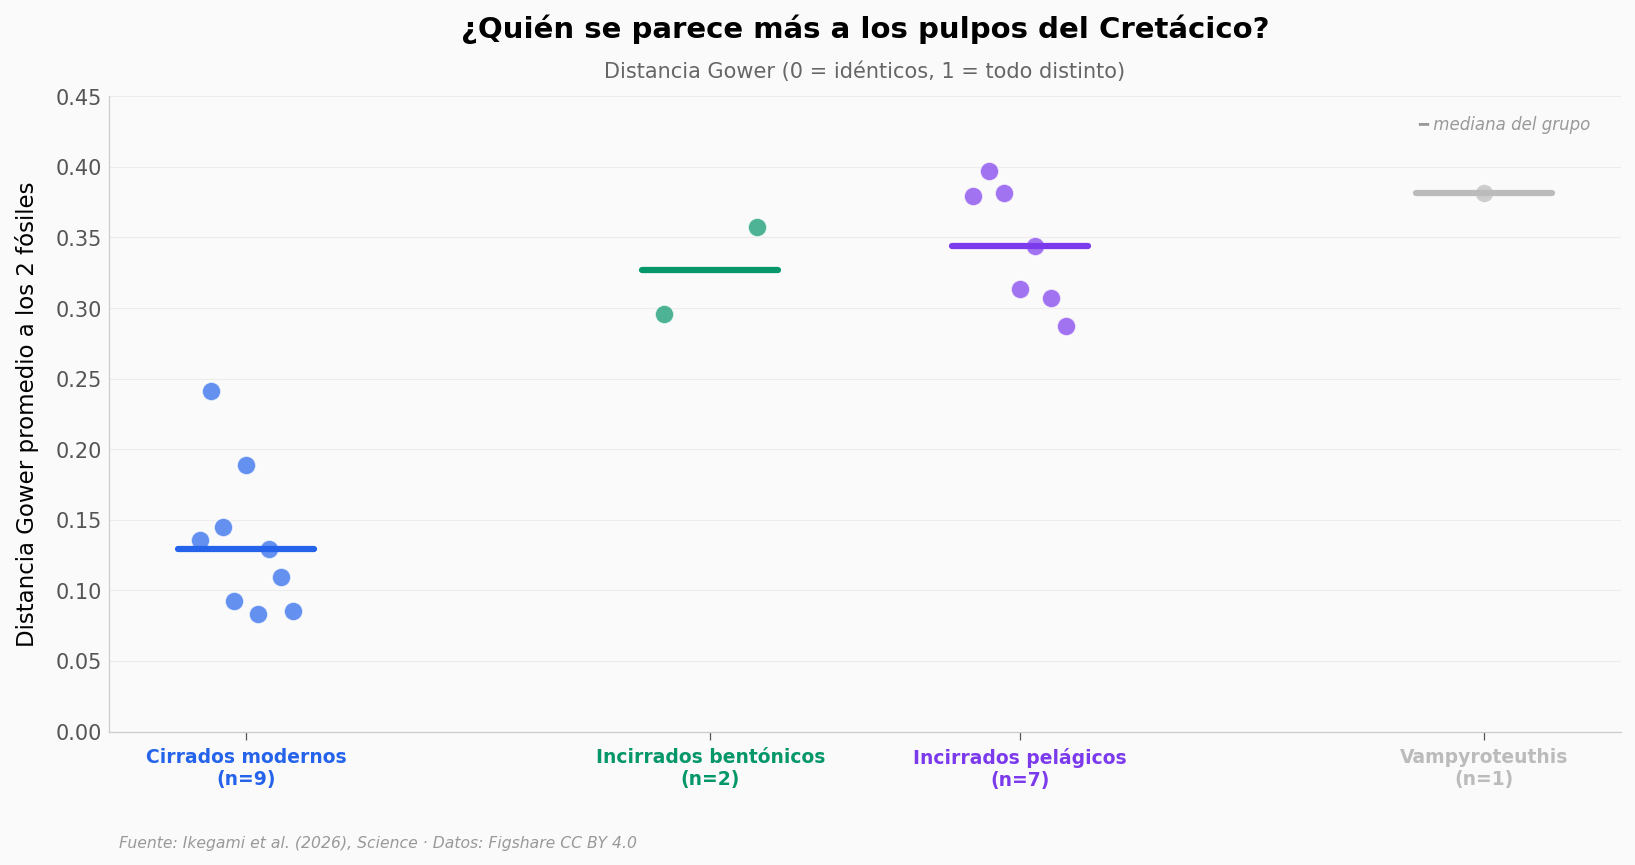

Cirrados (n=9):    rango 0.083-0.241, mediana 0.129
No-cirrados (n=10): rango 0.287-0.397, mediana 0.351
Ratio de medianas: 2.71×
Gap entre el cirrado más lejano y el no-cirrado más cercano: 0.046


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Construir grupos para mostrar
grupos_orden = [
    ('cirrate', COLOR_CIRRATE, 'Cirrados modernos'),
    ('incirrate_benthic', COLOR_INCIRRATE_BENTHIC, 'Incirrados bentónicos'),
    ('incirrate_pelagic', COLOR_INCIRRATE_PELAGIC, 'Incirrados pelágicos'),
    ('outgroup_vampyromorph', COLOR_OUTGROUP, 'Vampyroteuthis'),
]

np.random.seed(42)
positions = [0, 1.5, 2.5, 4]
labels = []
colores_tick = []

for i, (grupo, color, label) in enumerate(grupos_orden):
    sub = gower[gower['group'] == grupo]
    n = len(sub)
    vals = sub['dist_promedio'].values
    if n > 1:
        x_strip = np.linspace(positions[i] - 0.15, positions[i] + 0.15, n)
        np.random.shuffle(x_strip)
    else:
        x_strip = np.array([positions[i]])
    ax.scatter(x_strip, vals, color=color, s=80, alpha=0.7,
               edgecolors='white', linewidths=0.7, zorder=5)
    # Mediana como barra horizontal
    mediana = np.median(vals)
    ax.plot([positions[i] - 0.22, positions[i] + 0.22], [mediana, mediana],
            color=color, linewidth=3, solid_capstyle='round', zorder=6)
    labels.append(f'{label}\n(n={n})')
    colores_tick.append(color)

ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=9, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), colores_tick):
    tick.set_color(color)

ax.set_ylabel('Distancia Gower promedio a los 2 fósiles', fontsize=11)
ax.set_ylim(0, 0.45)

ax.set_title('¿Quién se parece más a los pulpos del Cretácico?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distancia Gower (0 = idénticos, 1 = todo distinto)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.text(0.98, 0.97, '━ mediana del grupo', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='top', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distancias_gower_por_grupo.png', dpi=200, bbox_inches='tight')
plt.show()

# Resumen numérico
cirr = gower[gower['group'] == 'cirrate']['dist_promedio']
nocirr = gower[gower['group'] != 'cirrate']['dist_promedio']
print(f'Cirrados (n={len(cirr)}):    rango {cirr.min():.3f}-{cirr.max():.3f}, mediana {cirr.median():.3f}')
print(f'No-cirrados (n={len(nocirr)}): rango {nocirr.min():.3f}-{nocirr.max():.3f}, mediana {nocirr.median():.3f}')
print(f'Ratio de medianas: {nocirr.median() / cirr.median():.2f}×')
print(f'Gap entre el cirrado más lejano y el no-cirrado más cercano: {nocirr.min() - cirr.max():.3f}')

## El golpe final

Los dos grupos no se mezclan. Pero ¿hay solape? ¿Algún cirrado raro está más lejos que algún incirrado raro?

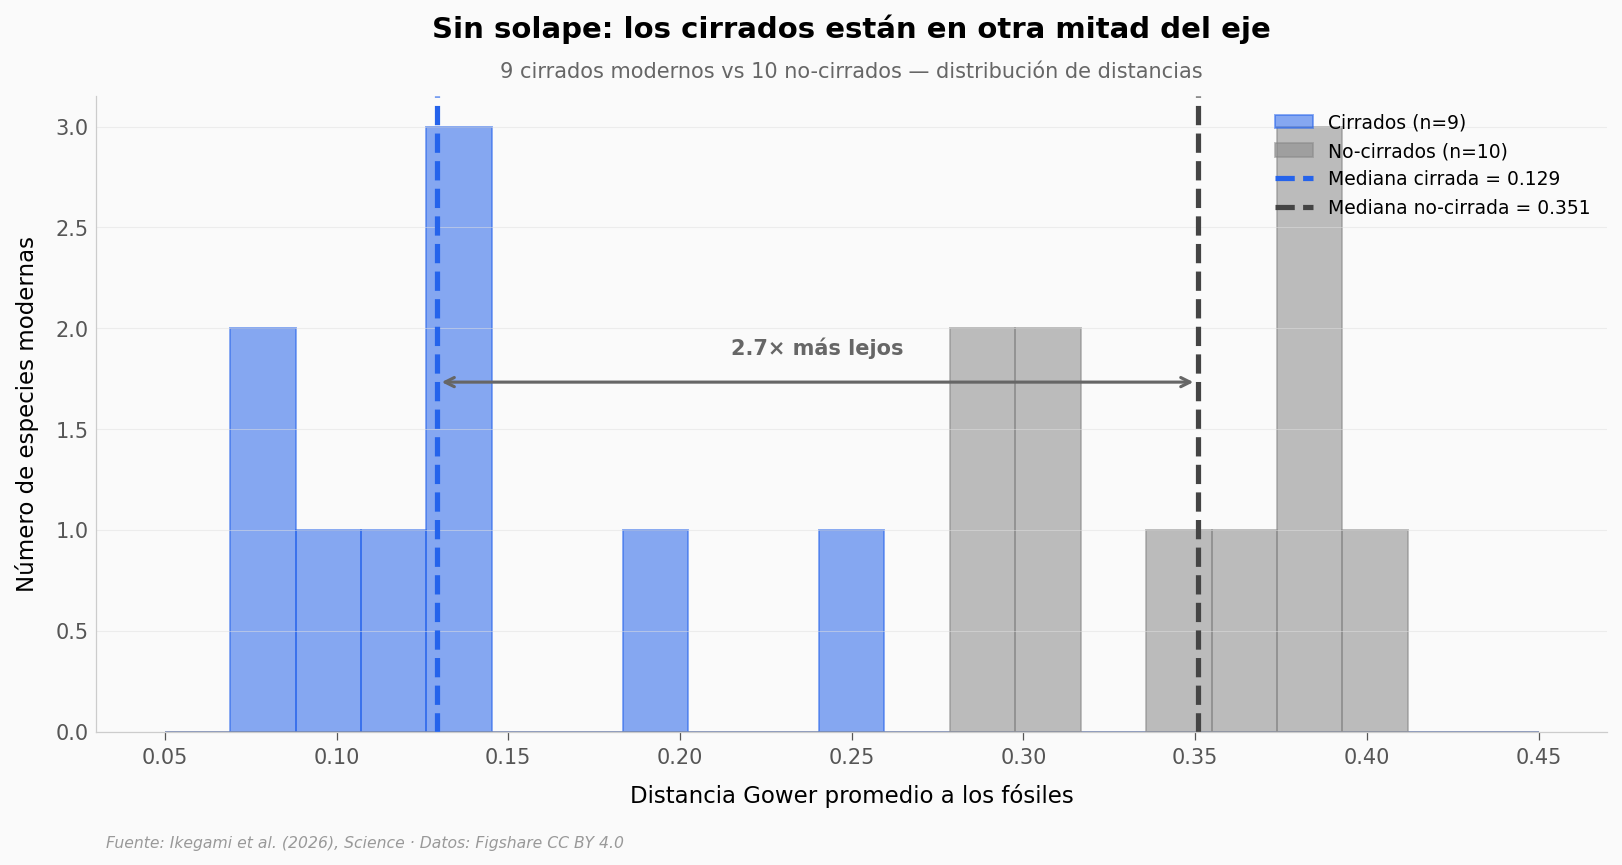

Cirrado más lejano: 0.241
No-cirrado más cercano: 0.287
Gap absoluto: +0.046
→ Los 9 cirrados están más cerca de los fósiles que CUALQUIERA de los 10 no-cirrados.


In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))

cirr_vals = gower[gower['group'] == 'cirrate']['dist_promedio'].values
nocirr_vals = gower[gower['group'] != 'cirrate']['dist_promedio'].values

bins = np.linspace(0.05, 0.45, 22)
ax.hist(cirr_vals, bins=bins, color=COLOR_CIRRATE, alpha=0.55,
        edgecolor=COLOR_CIRRATE, linewidth=0.9,
        label=f'Cirrados (n={len(cirr_vals)})')
ax.hist(nocirr_vals, bins=bins, color='#888888', alpha=0.55,
        edgecolor='#888888', linewidth=0.9,
        label=f'No-cirrados (n={len(nocirr_vals)})')

# Medianas
m_cirr = np.median(cirr_vals)
m_nocirr = np.median(nocirr_vals)
ax.axvline(m_cirr, color=COLOR_CIRRATE, linewidth=2.5, linestyle='--',
           label=f'Mediana cirrada = {m_cirr:.3f}')
ax.axvline(m_nocirr, color='#444444', linewidth=2.5, linestyle='--',
           label=f'Mediana no-cirrada = {m_nocirr:.3f}')

# Flecha bidireccional
y_arrow = ax.get_ylim()[1] * 0.55
ax.annotate('', xy=(m_nocirr, y_arrow), xytext=(m_cirr, y_arrow),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((m_cirr + m_nocirr) / 2, y_arrow * 1.08,
        f'{(m_nocirr / m_cirr):.1f}× más lejos',
        ha='center', fontsize=10, fontweight='bold', color='#666666')

ax.set_xlabel('Distancia Gower promedio a los fósiles', fontsize=11)
ax.set_ylabel('Número de especies modernas', fontsize=11)

ax.set_title('Sin solape: los cirrados están en otra mitad del eje',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '9 cirrados modernos vs 10 no-cirrados — distribución de distancias',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.legend(fontsize=9, loc='upper right', framealpha=0.92)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_distancias.png', dpi=200, bbox_inches='tight')
plt.show()

# Verificación cuantitativa del gap
print(f'Cirrado más lejano: {cirr_vals.max():.3f}')
print(f'No-cirrado más cercano: {nocirr_vals.min():.3f}')
gap = nocirr_vals.min() - cirr_vals.max()
print(f'Gap absoluto: {gap:+.3f}')
if gap > 0:
    print(f'→ Los 9 cirrados están más cerca de los fósiles que CUALQUIERA de los {len(nocirr_vals)} no-cirrados.')
else:
    print('→ Hay solape entre grupos.')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Los fósiles caen dentro del rango morfológico de los cirrados modernos | ✅ | PC1 de los fósiles entre -0,144 y -0,116; rango cirrado: -0,162 a -0,046. Total varianza 2D: 81,1% (Mardia fit = 0,921) |
| Los cirrados están más cerca de los fósiles que los no-cirrados | ✅ | Mediana cirrada 0,129 vs no-cirrada 0,351 (ratio 2,72×; Mann-Whitney U=0, p=0,0003; Cohen's d=4,5). 9 de 9 cirrados están más cerca que cualquier no-cirrado (gap absoluto 0,046, n=9 vs n=10) |
| Los pulpos cretácicos eran cirrados (Cirrata) | ⚠️ | Los datos morfológicos lo respaldan fuertemente, pero la asignación filogenética viene de un análisis cladístico aparte (en el paper). Aquí mostramos la afinidad morfológica, no la filogenia |
| Llegaban hasta 19 metros y 7 metros | ⚠️ | Dato del paper, derivado de medidas de mandíbula (Fig 4 del artículo). NO está en los CSVs descargados — los datos públicos analizan forma, no tamaño |
| Eran apex predators del Cretácico | ⚠️ | Inferencia ecológica del paper basada en tamaño + morfología funcional. Los CSVs no tienen marcadores tróficos |

> **Limitaciones:**
> - 19 caracteres morfológicos restringidos a la mandíbula. La similitud puede reflejar convergencia funcional (modo de alimentación), no necesariamente parentesco directo.
> - 21 taxa es una muestra modesta. Los 9 cirrados modernos cubren casi todos los géneros conocidos, pero la diversidad de incirrados queda submuestreada.
> - PCoA es proyección lineal. El 18,9% de varianza queda fuera del plano PC1-PC2.
> - Los fósiles son n=2. Generalizar a "todos los pulpos del Cretácico Tardío" desde dos especímenes requiere cautela.

## Ahora tú

¿Quieres explorar más allá de las medianas? Algunas preguntas con pista:

1. **¿Qué cirrado moderno es el más parecido a *N. jeletzkyi*?** Pista: ordena `gower` por `dist_a_jeletzkyi` y mira el top 3.
2. **¿Hay algún cirrado que se aleje del cluster?** Pista: en `pcoa`, filtra `group == 'cirrate'` y mira el rango de PC1 — uno de ellos cae más a la izquierda que el resto.
3. **¿Qué pasaría si quitas *Vampyroteuthis* del análisis?** Pista: es outgroup; sin él, ¿cambia la diferencia entre cirrados e incirrados?

In [5]:
# --- EXPERIMENTA AQUÍ ---
# Ranking de los 5 cefalópodos modernos más parecidos a cada fósil

print('═' * 60)
print('Más parecidos a Nanaimoteuthis jeletzkyi:')
print('═' * 60)
top_jeletzkyi = gower.nsmallest(5, 'dist_a_jeletzkyi')[
    ['taxon', 'group', 'dist_a_jeletzkyi']
]
print(top_jeletzkyi.to_string(index=False))

print()
print('═' * 60)
print('Más parecidos a Nanaimoteuthis haggarti:')
print('═' * 60)
top_haggarti = gower.nsmallest(5, 'dist_a_haggarti')[
    ['taxon', 'group', 'dist_a_haggarti']
]
print(top_haggarti.to_string(index=False))

print()
print('Top-5 en ambos casos: ¿qué grupo domina?')

════════════════════════════════════════════════════════════
Más parecidos a Nanaimoteuthis jeletzkyi:
════════════════════════════════════════════════════════════
                      taxon   group  dist_a_jeletzkyi
Opisthoteuthis californiana cirrate            0.0526
      Cirroctopus hochbergi cirrate            0.0722
      Opisthoteuthis bruuni cirrate            0.0899
    Stauroteuthis syrtensis cirrate            0.0965
       Grimpoteuthis boylei cirrate            0.1053

════════════════════════════════════════════════════════════
Más parecidos a Nanaimoteuthis haggarti:
════════════════════════════════════════════════════════════
                      taxon   group  dist_a_haggarti
    Stauroteuthis syrtensis cirrate           0.0702
      Cirroteuthis muelleri cirrate           0.0965
      Cirroctopus hochbergi cirrate           0.0985
Opisthoteuthis californiana cirrate           0.1316
      Cirroctopus glacialis cirrate           0.1491

Top-5 en ambos casos: ¿qué gr

## Fuentes

**Paper**: [Earliest octopuses were giant top predators in Cretaceous oceans](https://doi.org/10.1126/science.aea6285)  
*Science, 2026*

**Datos**: [Morphological disparity analyses of modern and Cretaceous octobrachian jaws (v1)](https://doi.org/10.6084/m9.figshare.29561630)  
*Figshare, CC BY 4.0*

*14 afirmaciones verificadas contra estas fuentes*

---

**Repositorio:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · CC BY 4.0
**Notebook reproducible:** ejecuta `jupyter execute notebook.ipynb` con `pandas`, `numpy`, `matplotlib`.